**Import Library**

In [83]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from google.colab import files


**Upload Dataset**

In [84]:
df = pd.read_csv("complete_labeled_dataset - complete_labeled_dataset.csv")
df.head()

,headline,label,importance,binary_label,confidence,source,label_name
0,"Markets Close Mostly Lower Again; ROST, PANW R...",Negative,major,1,1.0,original_labeled,major
1,"Gap plummets on earnings miss, cuts full-year ...",Negative,major,1,1.0,original_labeled,major
2,Billionaire Ken Fisher is Selling These 10 Stocks,Negative,non-major,0,1.0,original_labeled,non-major
3,"Corning net income drops 13%, shares fall",Negative,non-major,0,1.0,original_labeled,non-major
4,Internet Explorer shutdown to cause Japan prob...,Negative,non-major,0,1.0,original_labeled,non-major


**Bersihkan dan Sesuaikan Kolom**

In [85]:
# Select original columns and rename them to ensure clear, non-duplicate names
# Re-load df to ensure it has the original columns for processing in this cell
df = pd.read_csv("complete_labeled_dataset - complete_labeled_dataset.csv")

df_cleaned = pd.DataFrame({
    'headline': df['headline'],
    'sentiment': df['label'],
    'importance': df['label_name'] # Using 'label_name' as the intended 'importance' column
})
df = df_cleaned # Overwrite the original df with the cleaned one
df.head()

,headline,sentiment,importance
0,"Markets Close Mostly Lower Again; ROST, PANW R...",Negative,major
1,"Gap plummets on earnings miss, cuts full-year ...",Negative,major
2,Billionaire Ken Fisher is Selling These 10 Stocks,Negative,non-major
3,"Corning net income drops 13%, shares fall",Negative,non-major
4,Internet Explorer shutdown to cause Japan prob...,Negative,non-major


**Encode Label Sentiment & Importance**

In [86]:
le_sent = LabelEncoder()
le_imp  = LabelEncoder()

y_sent = le_sent.fit_transform(df['sentiment'])

# Ensure 'importance' column is a 1D Series before filling NaNs and fitting LabelEncoder.
# If df['importance'] is a DataFrame (e.g., due to unintended duplicate columns),
# select the first column to make it a Series.
if isinstance(df['importance'], pd.DataFrame):
    df['importance'] = df['importance'].iloc[:, 0]

# Fill NaN values in the 'importance' column of df with a new category
df['importance'] = df['importance'].fillna('unknown_importance')

# Now fit_transform le_imp on the cleaned 'importance' series
y_imp = le_imp.fit_transform(df['importance'])

# gabungkan ke satu dataframe label
y = pd.DataFrame({
    'sentiment': y_sent,
    'importance': y_imp
})

print("Sentiment classes:", le_sent.classes_)
print("Importance classes:", le_imp.classes_)

Sentiment classes: ['Negative' 'Neutral' 'Positive']
Importance classes: ['major' 'non-major']


**Train-Test Split**

In [87]:
# NaNs in 'importance' are now filled in the previous step, and df is cleaned
df_cleaned = df.copy()

X = df_cleaned['headline'].values

# Re-initialize and fit LabelEncoders in case previous cell was not run or kernel restarted
# This ensures le_sent and le_imp are fitted before transform is called
le_sent = LabelEncoder()
le_imp  = LabelEncoder()

# Need to fit on the *full* data to ensure all classes are learned
# The df used here should be the one after initial cleaning and NaN filling from previous steps
le_sent.fit(df_cleaned['sentiment'])
le_imp.fit(df_cleaned['importance'])

y_sent_cleaned = le_sent.transform(df_cleaned['sentiment'])

# 'importance' is now guaranteed to be a single Series without NaNs
cleaned_importance_series = df_cleaned['importance'] # Simplified

y_imp_cleaned = le_imp.transform(cleaned_importance_series)

y = pd.DataFrame({
    'sentiment': y_sent_cleaned,
    'importance': y_imp_cleaned
})

# Use the cleaned_importance_series for stratification
strat_key = df_cleaned['sentiment'] + "||" + cleaned_importance_series.astype(str)

X_train, X_test, y_train_df, y_test_df = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=strat_key
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 20800
Test size: 5200


**Pipeline Multinomial Logistic Regression (2 output sekaligus)**

In [88]:
# (Ensemble Method: Logistic Regression + Linear SVC)
from sklearn.ensemble import VotingClassifier
from sklearn.svm import LinearSVC

# 1. Definisi Model Anggota Tim
# Model A: Logistic Regression (Settingan terbaik kita tadi)
clf_lr = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    max_iter=1000,
    C=1.0,
    random_state=42
)

# Model B: Linear SVC (Sangat kuat untuk teks & Precision)
# Kita set class_weight='balanced' agar dia membantu mengangkat Recall yang susah dideteksi
clf_svm = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=2000,
    dual=False # Disarankan False untuk n_samples > n_features
)

# 2. Membuat Voting Classifier (Gabungan)
# voting='hard' artinya mereka akan voting kelas mana yang menang (Majority Rule)
voting_clf = VotingClassifier(
    estimators=[
        ('lr', clf_lr),
        ('svm', clf_svm)
    ],
    voting='hard'
)

# 3. Masukkan ke dalam MultiOutput dan Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=25000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        stop_words=None
    )),
    ('clf', MultiOutputClassifier(voting_clf))
])

print("Melatih Model Ensemble (Logistic Regression + SVM)...")
print("Tujuannya: Menaikkan F1-Score dengan menggabungkan dua logika berbeda.")

pipeline.fit(X_train, y_train_df)
print("Training Ensemble Selesai.")

Melatih Model Ensemble (Logistic Regression + SVM)...
Tujuannya: Menaikkan F1-Score dengan menggabungkan dua logika berbeda.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


Training Ensemble Selesai.


**Evaluasi Model**

In [89]:
# predict
pred = pipeline.predict(X_test)
pred_df = pd.DataFrame(pred, columns=['sentiment','importance'])

# decode ke label asli
sent_true = le_sent.inverse_transform(y_test_df['sentiment'])
sent_pred = le_sent.inverse_transform(pred_df['sentiment'])

imp_true = le_imp.inverse_transform(y_test_df['importance'])
imp_pred = le_imp.inverse_transform(pred_df['importance'])

print("=== SENTIMENT REPORT ===")
print(classification_report(sent_true, sent_pred))

print("=== IMPORTANCE REPORT ===")
print(classification_report(imp_true, imp_pred))

print("Sentiment Accuracy:", accuracy_score(sent_true, sent_pred))
print("Importance Accuracy:", accuracy_score(imp_true, imp_pred))


=== SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative       0.71      0.74      0.73       961
     Neutral       0.72      0.70      0.71      1749
    Positive       0.77      0.77      0.77      2490

    accuracy                           0.74      5200
   macro avg       0.73      0.74      0.73      5200
weighted avg       0.74      0.74      0.74      5200

=== IMPORTANCE REPORT ===
              precision    recall  f1-score   support

       major       0.95      0.95      0.95       975
   non-major       0.99      0.99      0.99      4225

    accuracy                           0.98      5200
   macro avg       0.97      0.97      0.97      5200
weighted avg       0.98      0.98      0.98      5200

Sentiment Accuracy: 0.7407692307692307
Importance Accuracy: 0.9823076923076923


**Confusion Matrix**

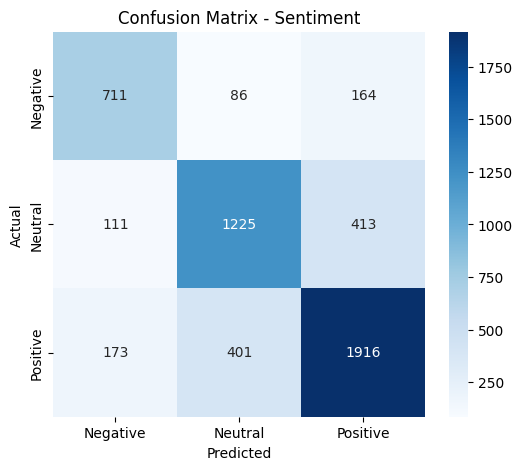

In [90]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(sent_true, sent_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_sent.classes_,
            yticklabels=le_sent.classes_)
plt.title("Confusion Matrix - Sentiment")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [91]:
import joblib
import os

# Nama file yang kita sepakati (sesuai isi modelnya Ensemble)
filename = "Ensemble_Model_Final.pkl"

print("Sedang menyimpan model...")

# 1. SIMPAN MODEL (DUMP)
joblib.dump(
    {
        "pipeline": pipeline,             # Model Ensemble (VotingClassifier)
        "sentiment_encoder": le_sent,     # Encoder Sentiment
        "importance_encoder": le_imp,     # Encoder Importance
        "input_features": "headline"
    },
    filename
)

print(f"✅ Berhasil menyimpan file: {filename}")

# 2. CEK APAKAH FILE BENAR-BENAR ADA (Debugging)
if filename in os.listdir():
    print(f"File ditemukan di sistem: {filename}")
else:
    print("⚠️ File TIDAK ditemukan! Cek izin penyimpanan.")

# 3. LOAD KEMBALI (Untuk memastikan file bisa dibaca)
print("Mencoba me-load kembali model...")
loaded_model_data = joblib.load(filename)
MLR = loaded_model_data # Assign ke variabel MLR

print("✅ Model berhasil di-load kembali dan siap digunakan!")

Sedang menyimpan model...
✅ Berhasil menyimpan file: Ensemble_Model_Final.pkl
File ditemukan di sistem: Ensemble_Model_Final.pkl
Mencoba me-load kembali model...
✅ Model berhasil di-load kembali dan siap digunakan!


In [92]:
# 1. Ambil vocab dari TF-IDF
vect = pipeline.named_steps['tfidf']
feature_names = vect.get_feature_names_out()

# 2. Ambil model Voting untuk Sentiment (Estimator ke-0 dari MultiOutput)
voting_clf = pipeline.named_steps['clf'].estimators_[0]

print("=== MODEL ENSEMBLE (VOTING) ===")

# 3. Kita harus loop ke dalam anggota voting (Logistic Regression & SVM)
# voting_clf.estimators_ berisi list model yang sudah dilatih [LogReg, SVM]
model_names = ['Logistic Regression (Probabilitas)', 'Linear SVC (Garis Tegas)']

for model_name, sub_model in zip(model_names, voting_clf.estimators_):
    print(f"\n{'='*20} {model_name} {'='*20}")

    # Loop untuk setiap kelas sentimen (Negatif, Netral, Positif)
    for i, label in enumerate(le_sent.classes_):
        # Ambil koefisien dari sub-model
        if hasattr(sub_model, 'coef_'):
            # Ambil 10 kata dengan bobot terbesar
            top_indices = np.argsort(sub_model.coef_[i])[-10:]
            top_words = [feature_names[j] for j in top_indices]

            # Balik urutan biar yang paling penting di depan
            top_words = top_words[::-1]

            print(f"  -> Kelas '{label}': {', '.join(top_words)}")
        else:
            print(f"  (Model {model_name} tidak mendukung fitur coef_)")

=== MODEL ENSEMBLE (VOTING) ===

==================== Logistic Regression (Probabilitas) ====================
  -> Kelas 'Negative': down, decline, fall, misses, sells, lower, falls, miss, loss, stock moves
  -> Kelas 'Neutral': stocks to, stocks, best, top, warren, your, buy, picks, 2022, to buy
  -> Kelas 'Positive': up, announces, beat, higher, surpasses, up since, launches, and, expands, to

==================== Linear SVC (Garis Tegas) ====================
  -> Kelas 'Negative': down, decline, sells, fall, misses, lower, declare, stock moves, delays, declines
  -> Kelas 'Neutral': warren, stocks to, picks, best, your, should retain, top, warren buffett, stocks, cards for
  -> Kelas 'Positive': surpasses, up since, beat, up, announces, is top, higher, surges, expands, despite
